# 01 — Exploratory Data Analysis (EDA)
**Dataset:** Credit Card Fraud Detection — Kaggle (284,807 transaksione)

Qëllimi: Kuptojmë strukturën e dataset-it, shpërndarjen e variablave, çekuilibrin e klasave dhe korrelacionet mes featureve.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f'Dataset u ngarkua me sukses!')
print(f'Dimensionet: {df.shape[0]:,} rreshta  x  {df.shape[1]} kolona')
df.head()

Dataset u ngarkua me sukses!
Dimensionet: 284,807 rreshta  x  31 kolona


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 1. Informacioni Bazë i Dataset-it
Kontrollojmë dimensionet, tipet e kolonave, vlerat null dhe duplikatet.

In [3]:
print("=" * 50)
print("INFORMACIONI BAZË I DATASET-IT")
print("=" * 50)
print(f"\nNumri i rreshtave : {df.shape[0]:,}")
print(f"Numri i kolonave  : {df.shape[1]}")
print(f"\nTipet e kolonave:")
print(df.dtypes.value_counts().to_string())
print(f"\nVlera null (totale): {df.isnull().sum().sum()}")
print(f"Rreshta duplikatë : {df.duplicated().sum()}")

INFORMACIONI BAZË I DATASET-IT

Numri i rreshtave : 284,807
Numri i kolonave  : 31

Tipet e kolonave:
float64    30
int64       1

Vlera null (totale): 0
Rreshta duplikatë : 1081


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,...,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,...,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,...,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,...,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,...,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,...,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,...,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


## 2. Analiza e Çekuilibrit të Klasave (Class Imbalance)
Njëra nga sfidat kryesore në fraud detection: klasa e mashtrimit është shumë e nënpërfaqësuar.

In [5]:
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print("=" * 50)
print("SHPËRNDARJA E KLASAVE")
print("=" * 50)
print(f"Transaksione legjitime  (0): {class_counts[0]:>7,}  ({class_pct[0]:.3f}%)")
print(f"Transaksione mashtruese (1): {class_counts[1]:>7,}  ({class_pct[1]:.3f}%)")
print(f"\nRaporti i çekuilibrit: {class_counts[0] / class_counts[1]:.0f}:1")

SHPËRNDARJA E KLASAVE
Transaksione legjitime  (0): 284,315  (99.827%)
Transaksione mashtruese (1):     492  (0.173%)

Raporti i çekuilibrit: 578:1


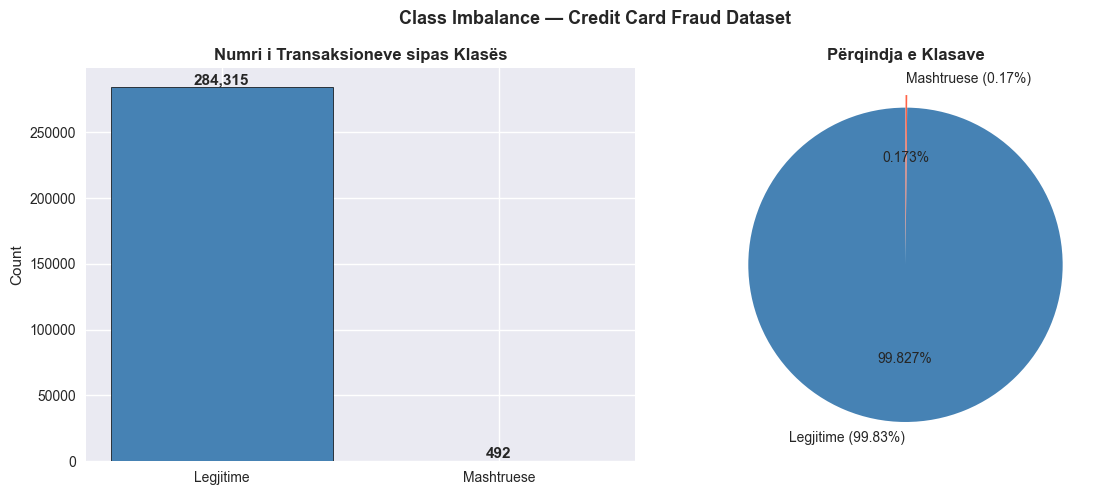

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Legjitime', 'Mashtruese'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Numri i Transaksioneve sipas Klasës', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(class_counts.values,
            labels=['Legjitime (99.83%)', 'Mashtruese (0.17%)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.3f%%', startangle=90, explode=(0, 0.08))
axes[1].set_title('Përqindja e Klasave', fontweight='bold')

plt.suptitle('Class Imbalance — Credit Card Fraud Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analiza e Featureve Amount dhe Time
`Amount` (shuma e transaksionit) dhe `Time` (sekonda nga transaksioni i parë) janë dy featurat e patransformuara me PCA.

In [7]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("=== Statistikat e Amount sipas Klasës ===")
print(df.groupby('Class')['Amount'].describe().round(2))
print(f"\nAmount mesatar — Legjitime : ${legit['Amount'].mean():.2f}")
print(f"Amount mesatar — Mashtruese: ${fraud['Amount'].mean():.2f}")
print(f"Amount maksimal — Legjitime : ${legit['Amount'].max():,.2f}")
print(f"Amount maksimal — Mashtruese: ${fraud['Amount'].max():,.2f}")

=== Statistikat e Amount sipas Klasës ===
            count     mean      std    min    25%     50%      75%        max
Class                                                                        
0     284315.0000  88.2900 250.1100 0.0000 5.6500 22.0000  77.0500 25691.1600
1        492.0000 122.2100 256.6800 0.0000 1.0000  9.2500 105.8900  2125.8700

Amount mesatar — Legjitime : $88.29
Amount mesatar — Mashtruese: $122.21
Amount maksimal — Legjitime : $25,691.16
Amount maksimal — Mashtruese: $2,125.87


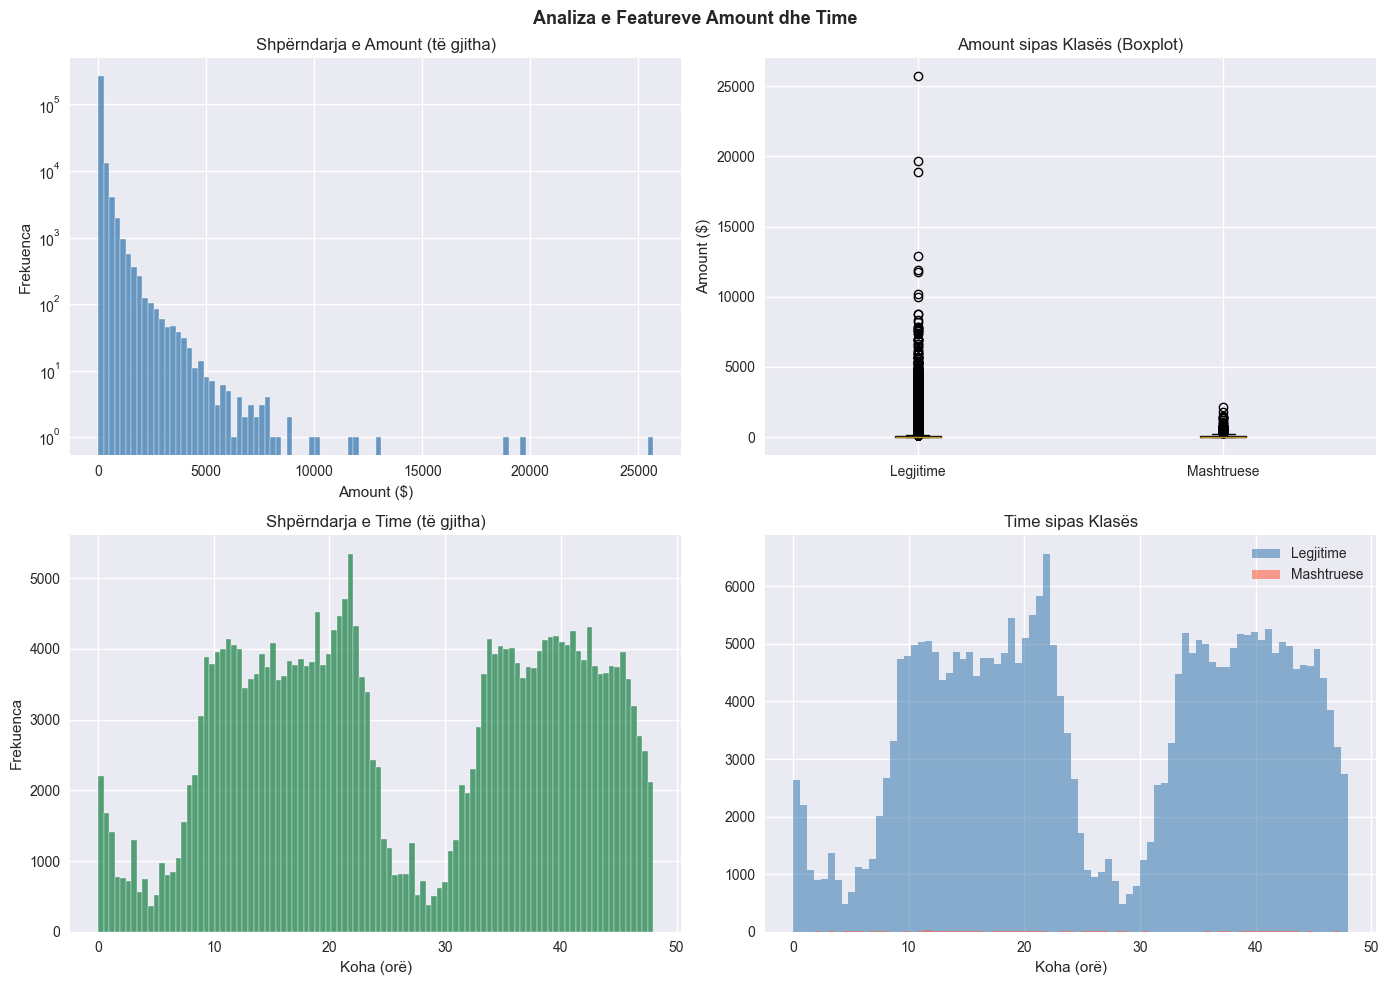

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Amount'], bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Shpërndarja e Amount (të gjitha)')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Frekuenca')
axes[0, 0].set_yscale('log')

axes[0, 1].boxplot([legit['Amount'], fraud['Amount']],
                   labels=['Legjitime', 'Mashtruese'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[0, 1].set_title('Amount sipas Klasës (Boxplot)')
axes[0, 1].set_ylabel('Amount ($)')

axes[1, 0].hist(df['Time'] / 3600, bins=100, color='seagreen', alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Shpërndarja e Time (të gjitha)')
axes[1, 0].set_xlabel('Koha (orë)')
axes[1, 0].set_ylabel('Frekuenca')

axes[1, 1].hist(legit['Time'] / 3600, bins=80, alpha=0.6, label='Legjitime', color='steelblue')
axes[1, 1].hist(fraud['Time'] / 3600, bins=80, alpha=0.6, label='Mashtruese', color='tomato')
axes[1, 1].set_title('Time sipas Klasës')
axes[1, 1].set_xlabel('Koha (orë)')
axes[1, 1].legend()

plt.suptitle('Analiza e Featureve Amount dhe Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/amount_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analiza e Korrelacioneve
Gjejmë cilat feature V1–V28 kanë korrelacionin më të lartë me variablin target `Class`.

In [9]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("=== Top 10 Features me Korrelacion ndaj Class ===")
print(corr_with_class.head(10).round(4))

=== Top 10 Features me Korrelacion ndaj Class ===
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V11    0.1549
V4     0.1334
V18   -0.1115
Name: Class, dtype: float64


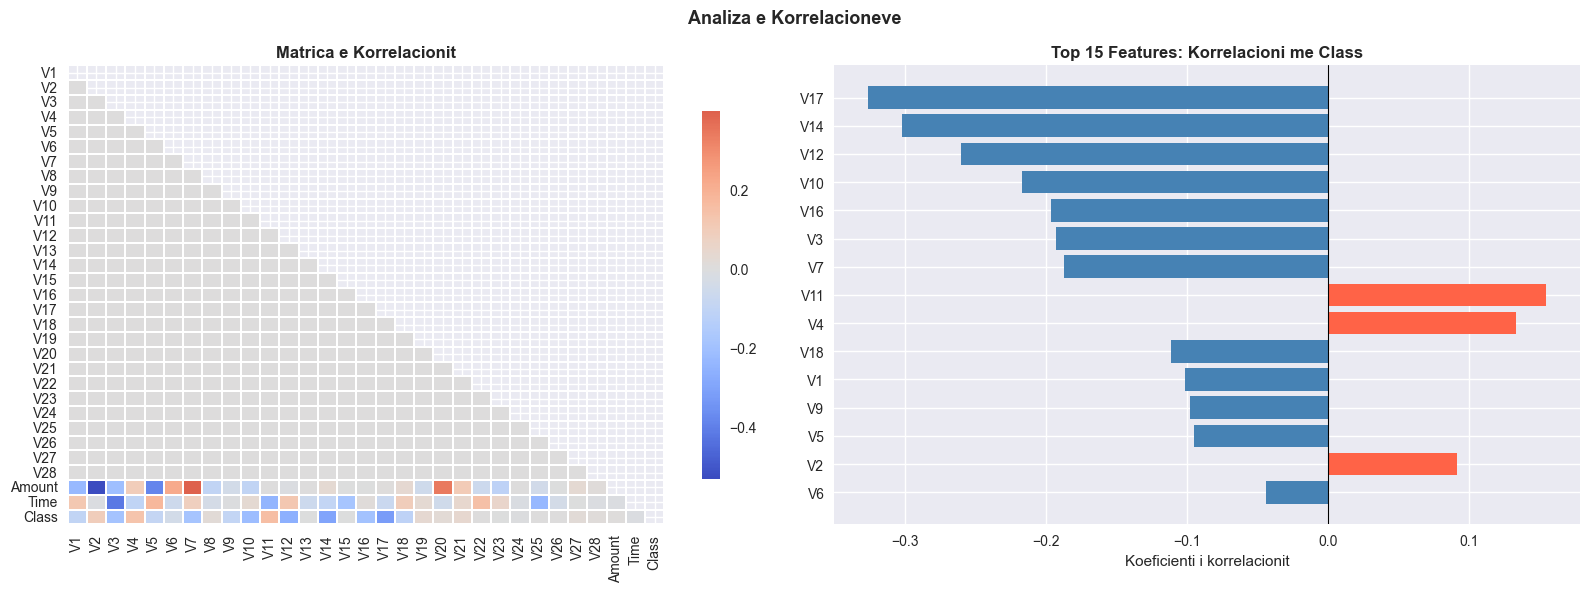

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

v_cols = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time', 'Class']
corr_matrix = df[v_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            ax=axes[0], cbar_kws={'shrink': 0.8}, linewidths=0.1)
axes[0].set_title('Matrica e Korrelacionit', fontweight='bold')

colors = ['tomato' if x > 0 else 'steelblue' for x in corr_with_class.head(15).values]
axes[1].barh(corr_with_class.head(15).index[::-1],
             corr_with_class.head(15).values[::-1], color=colors[::-1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 Features: Korrelacioni me Class', fontweight='bold')
axes[1].set_xlabel('Koeficienti i korrelacionit')

plt.suptitle('Analiza e Korrelacioneve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Krahasimi i Featureve: Fraud vs Legjitime
Shikojmë shpërndarjen e 6 featureve me korrelacionin më të lartë ndaj Class.

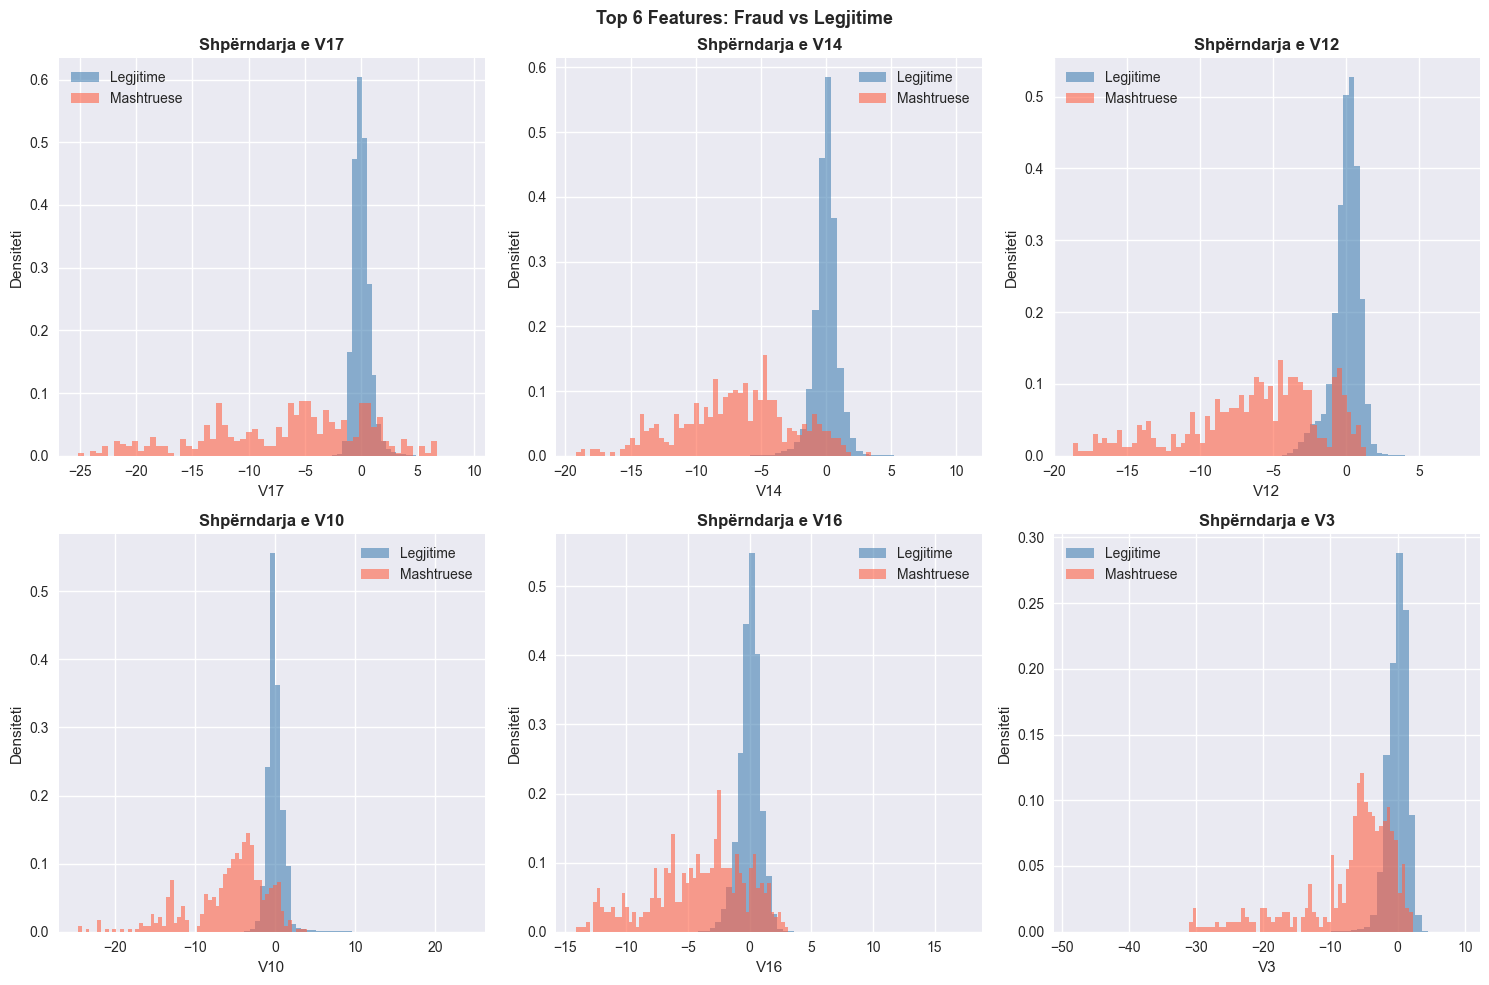

In [11]:
top_features = corr_with_class.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].hist(legit[feature], bins=60, alpha=0.6, label='Legjitime',
                 color='steelblue', density=True)
    axes[i].hist(fraud[feature], bins=60, alpha=0.6, label='Mashtruese',
                 color='tomato', density=True)
    axes[i].set_title(f'Shpërndarja e {feature}', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Densiteti')
    axes[i].legend()

plt.suptitle('Top 6 Features: Fraud vs Legjitime', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Konkluzionet dhe Insights kryesore

### Çfarë mësuam nga EDA:

**1. Çekuilibri i klasave (Class Imbalance)**
- 284,315 transaksione legjitime (99.83%) kundrejt 492 mashtruese (0.17%)
- Raporti 578:1 — accuracy e thjeshtë nuk mjafton si metrikë
- Kërkohet SMOTE ose teknika të tjera balancimi para trajnimit

**2. Featurat V1–V28**
- Janë rezultat i PCA (të transformuara, të anonimizuara)
- Nuk kanë nevojë për normalizim shtesë mes tyre
- V4, V11, V14, V17 kanë korrelacionin më të lartë me Class

**3. Amount dhe Time**
- Amount: transaksionet mashtruese kanë shumë mesatare më të ulët ($122 vs $88)
- Time: nuk tregon pattern të qartë — fraudet ndodhin në çdo moment
- Të dyja kanë nevojë për StandardScaler para trajnimit

**4. Implikime për modelim**
- Metrikat kryesore: **Recall** dhe **F1-score** (jo accuracy)
- Prioritet: minimizimi i False Negatives (fraud i pazbuluar)
- Preprocessing i domosdoshëm: scaling i Amount + Time, SMOTE për balancim